## Photo Classification by genre
#### Test datas:
###### Name: Sándor Balázs
###### Neptun ID: AZA6NL
###### Network: ResNet18
###### Objects: PhotoDB

### GitHub repository for the assignment:
https://github.com/SandorBalazsHU/elte-ik-msc-thesis
### The own dataset:
https://drive.google.com/drive/folders/1tI_4lpFtdm3cvkHvUJw7WzLzZ1Wb7iIp?usp=sharing

## 1. Import libraries
Import all libraries/packages and initialize the device. (CUDA in tis case)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler # customize the training
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
import warnings
warnings.filterwarnings("ignore") 

print(torch.cuda.is_available())
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
torch.zeros(1).cuda()

True
cuda:0


tensor([0.], device='cuda:0')

## 2. Dataset
Loading the dataset, split it and introduce it.

### The dataset's structure.
My dataset created by me from my own photo library. I chose 8500 photos from my phot library and i categorized them by 16 genre, i wrote a script wich can convert the Nikon raw .nef format to .jpg and resize the images to 224 with for the ResNet. Then i wrote a script wich rename the images and an another wich split the images to training, test and validation set (50-25-25).

The used scripts are available in the project repository.

The selected classes:

aircraft_in_air, aircraft_on_ground, animal, architecture, astro, fireworks, forest, interior, item, landscape, macro, music, nature, people, street, vehicle

The used dataset sizes:

train: 4246

validation: 2119

test: 213    

### Batch size
I have a 4GB GPU, for this size the 64 batch seemed size is ideal for two modells and a correct running time.

### Image transformation
Because the ResNet18 model is designed for images of size 224, I scale it to that size and then do random transformations.

### Pre-processing the dataset (data loader with transformations)

In [2]:
Batch_size=64;

#Size 224 is ideal for ResNet18
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomAffine(degrees=(5, 50), translate=(0.1, 0.3), scale=(0.9, 1.1)),
        transforms.RandomPerspective(distortion_scale=0.2),
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'sample_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val', 'test']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=Batch_size, shuffle=True, num_workers=4) for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
print("Readed classes: ")
print(class_names)
print("Readed dataset sizes: ")
print(dataset_sizes)

Readed classes: 
['aircraft_in_air', 'aircraft_on_ground', 'animal', 'architecture', 'astro', 'fireworks', 'forest', 'interior', 'item', 'landscape', 'macro', 'music', 'nature', 'people', 'street', 'vehicle']
Readed dataset sizes: 
{'train': 4247, 'val': 2119, 'test': 2135}


### Load the given pre-trained model

In [3]:
model = models.resnet18()

### Build the basic model.

In [4]:
#Random weights for the modell
model = models.resnet18()
numrs = model.fc.in_features

model.fc = nn.Linear(numrs, len(class_names))
model = model.to(device)

#CrossEntropyLoss loss function
criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

#### ---> Load the own retrained modell and skip the training

In [6]:
model.load_state_dict(torch.load('resnet_trained/resnet18_basic.pth'))

<All keys matched successfully>

### Visualize some resoults

In [11]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)

In [12]:
def visualize_model(model, num_images=10):
    was_training = model.training
    model.eval()
    images_so_far = 0

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                fig = plt.figure(figsize=(10,10))
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

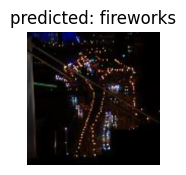

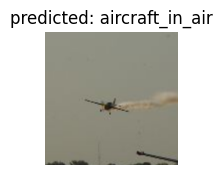

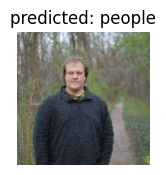

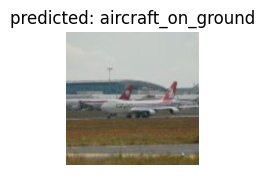

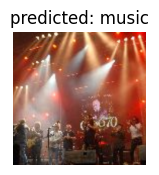

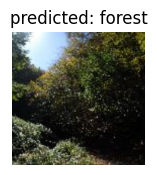

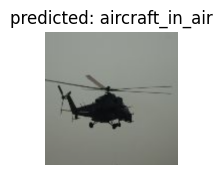

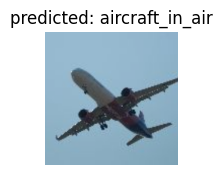

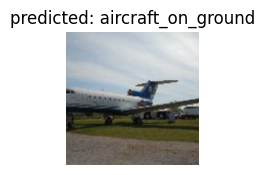

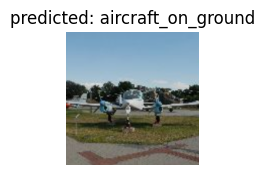

In [13]:
visualize_model(model)

#### 4. Implement the new architecture with less parameter

### The finetuned modell

In [14]:
#Pretrained from ImageNet.
model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 5.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

model_ft = model_ft.to(device)

#Same loss function
criterion = nn.CrossEntropyLoss() # BinaryCrossEntropyLoss

#SGD OPTIMIZER
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

#### ---> Load the own retrained modell and skip the training

In [16]:
model.load_state_dict(torch.load('resnet_trained/resnet18_basic_2.pth'))

<All keys matched successfully>

### Show some resoults.

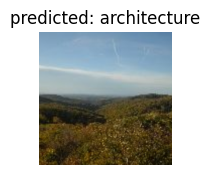

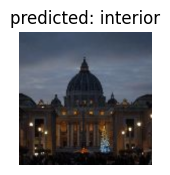

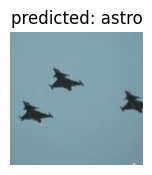

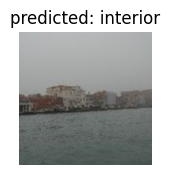

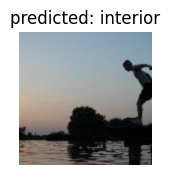

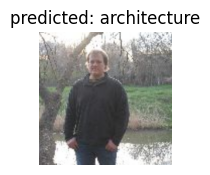

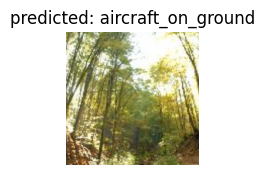

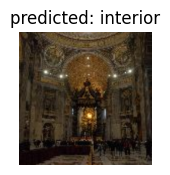

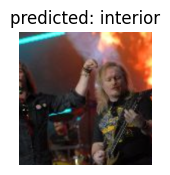

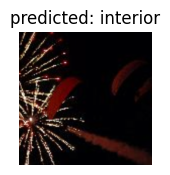

In [17]:
visualize_model(model_ft)

## 5. Final
### The fine tuned modell was better